# SIRT_CUDA_positivity Reconstruction with FSC Resolution Analysis

This notebook loads pre-aligned projections, reconstructs them using SIRT_CUDA with a positivity constraint (`MinConstraint=0`), and measures resolution via Fourier Shell Correlation (FSC). This matches the best-performing configuration from `main.py`: `{'label': 'SIRT_CUDA_positivity', 'num_iter': 400, 'extra_options': {'MinConstraint': 0}}`.

## Imports

In [1]:
import os
import time
import numpy as np
import h5py
import tomopy
import matplotlib.pyplot as plt
from datetime import datetime

import tomoDataClass
from helperFunctions import convert_to_numpy, convert_to_tiff

[gpu] active backends: cupy, torch-GPU, svmbir


## Configuration

In [2]:
# Path to aligned projections TIFF file
TIFF_FILE = '/home/ljh79/TomoMono/alignedProjections/APSbeamtime_Oct25/cfg_fullres_aligned_20260514-115952.tif'

# Path to raw data for angle information
RAW_HDF5 = '/home/ljh79/groups/grp_ptychi/nobackup/autodelete/Oct2025APSdata/tomo_data_run_final_2.hdf5'

# Angles to drop (broken projections)
DROP_ANGLES = [19, 26]

# Reconstruction parameters — SIRT_CUDA_positivity (best run from main.py)
alg = 'SIRT_CUDA'
NUM_ITER = 400
MinConstraint = 0
EXTRA_OPTIONS = {'MinConstraint': MinConstraint}  # positivity constraint: clip voxels to >= 0 each iteration

# ## Alternative parameters
# alg = 'gridrec'
# NUM_ITER = None
# MinConstraint = None
# EXTRA_OPTIONS = {}  # no extra options for gridrec

# Optional: crop parameters (None = no crop)
Y_START = 40
Y_END = 440
WIDTH = 1200  # Full width if None, or specify centered width

## Load Aligned Projections

In [3]:
print(f'Loading projections: {TIFF_FILE}')
t0 = time.time()
projections, scale_info = convert_to_numpy(TIFF_FILE)
projections = projections.astype(np.float32)
# projections = projections[::, ::4, ::4]
print(f'  shape (n_angles, h, w): {projections.shape}  [{time.time()-t0:.1f}s]')

Loading projections: /home/ljh79/TomoMono/alignedProjections/APSbeamtime_Oct25/cfg_fullres_aligned_20260514-115952.tif
  shape (n_angles, h, w): (556, 585, 1810)  [2.7s]


## Load Angles

In [4]:
print(f'Loading angles from: {RAW_HDF5}')
with h5py.File(RAW_HDF5, 'r') as hf:
    ang_deg = hf['angles'][...]

ang_rad = ang_deg * np.pi / 180.0
if DROP_ANGLES:
    ang_rad = np.delete(ang_rad, DROP_ANGLES, axis=0)
angles = (ang_rad - np.mean(ang_rad)).astype(np.float32)

assert len(angles) == projections.shape[0], (
    f'Angle count {len(angles)} != projection count {projections.shape[0]}. '
    f'Check DROP_ANGLES.'
)
print(f'  angles: {len(angles)}  '
      f'range [{np.degrees(angles.min()):.2f}, {np.degrees(angles.max()):.2f}] deg')

Loading angles from: /home/ljh79/groups/grp_ptychi/nobackup/autodelete/Oct2025APSdata/tomo_data_run_final_2.hdf5
  angles: 556  range [-65.63, 65.17] deg


## Apply Cropping (Optional)

In [5]:
# projections = projections[:, ::2, ::2]

h, w = projections.shape[1], projections.shape[2]
y_start = Y_START if Y_START is not None else 0
y_end = Y_END if Y_END is not None else h
y_start, y_end = max(0, y_start), min(h, y_end)

if WIDTH is not None and WIDTH < w:
    cx = w // 2
    half = WIDTH // 2
    projections = projections[:, y_start:y_end, cx - half : cx + half]
else:
    projections = projections[:, y_start:y_end, :]

print(f'Crop: y=[{y_start}, {y_end})  '
      f'x=[{w//2 - (WIDTH or w)//2}, {w//2 + (WIDTH or w)//2})')
print(f'Final shape: {projections.shape}')

Crop: y=[40, 440)  x=[305, 1505)
Final shape: (556, 400, 1200)


## Normalize Projections

In [6]:
print('\nNormalizing (phase data: invert + scale to [0, 1])...')
projections = -projections
projections -= projections.min()
projections /= projections.max()
print(f'Range after normalization: [{projections.min():.4f}, {projections.max():.4f}]')


Normalizing (phase data: invert + scale to [0, 1])...
Range after normalization: [0.0000, 1.0000]


## Create tomoData Object

In [7]:
print('\nCreating tomoData object...')
tomo = tomoDataClass.tomoData(projections, angles)
rotation_center = float(tomopy.find_center_vo(tomo.finalProjections))
tomo.center_offset = rotation_center - tomo.image_size[1] / 2
print(f'Rotation center: {rotation_center:.2f}')
print(f'Center offset: {tomo.center_offset:.2f}')
del projections  # Free memory


Creating tomoData object...
Rotation center: 596.50
Center offset: -3.50


## Reconstruct with SIRT_CUDA


Reconstructing with SIRT_CUDA (400 iterations, ExtraOptions={'MinConstraint': 0})...


Using GPU-accelerated reconstruction, Algorithm:  SIRT_CUDA
Reconstruction completed.
Reconstruction completed in 1215.0s
Reconstruction shape: (400, 1200, 1200)
Reconstruction range: [0.0000, 0.0017]


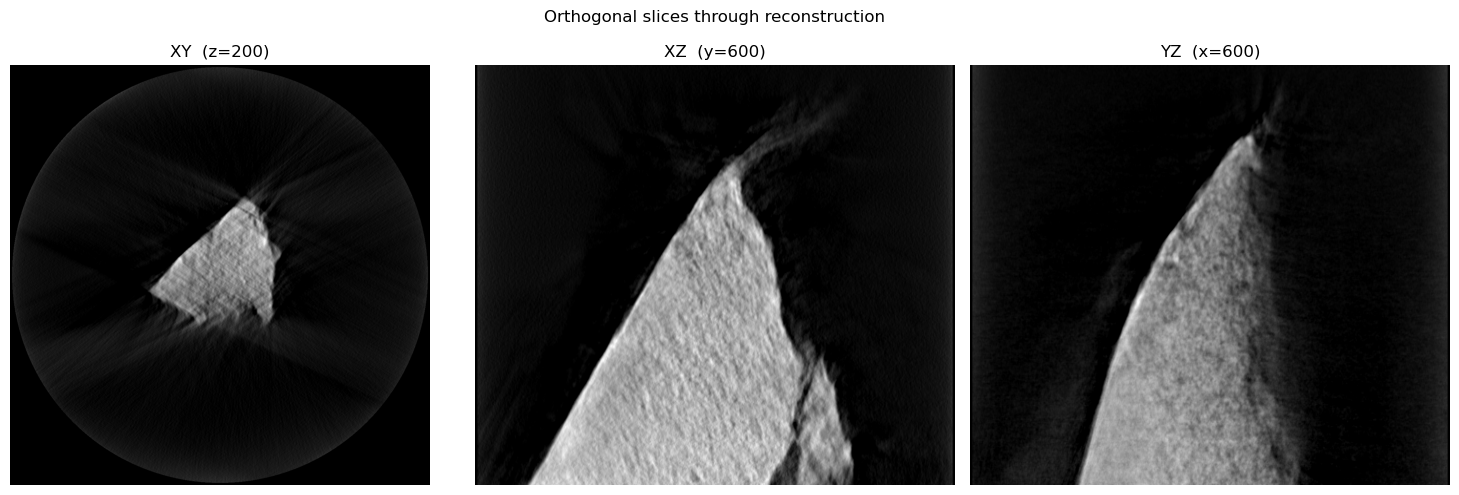

In [8]:
print(f'\nReconstructing with {alg} ({NUM_ITER} iterations, ExtraOptions={EXTRA_OPTIONS})...')
t_start = time.time()
tomo.reconstruct(algorithm=alg, num_iter=NUM_ITER, extra_options=EXTRA_OPTIONS)
elapsed = time.time() - t_start
print(f'Reconstruction completed in {elapsed:.1f}s')
print(f'Reconstruction shape: {tomo.recon.shape}')
print(f'Reconstruction range: [{tomo.recon.min():.4f}, {tomo.recon.max():.4f}]')

tomo.displayReconOrthogonalSlices()

## Compute FSC Resolution

In [9]:
pad_len=100


Computing Fourier Shell Correlation (FSC)...



Fourier Shell Correlation  (algorithm=SIRT_CUDA)
  Half 1 (even angles): 278 projections
  Half 2 (odd  angles): 278  projections
  Reconstructing half 1 …
  Reconstructing half 2 …
  Background-subtracted halves (median): b1=6.312e-05, b2=6.245e-05
  Square crop: XY 1200×1200 → 838×838 px (inscribed square, no masking)
  Pad+taper (all axes): +100 px/face (edge-replicated), 50 px Hann taper rolling the object edge to zero → half-map shape (600, 1038, 1038)


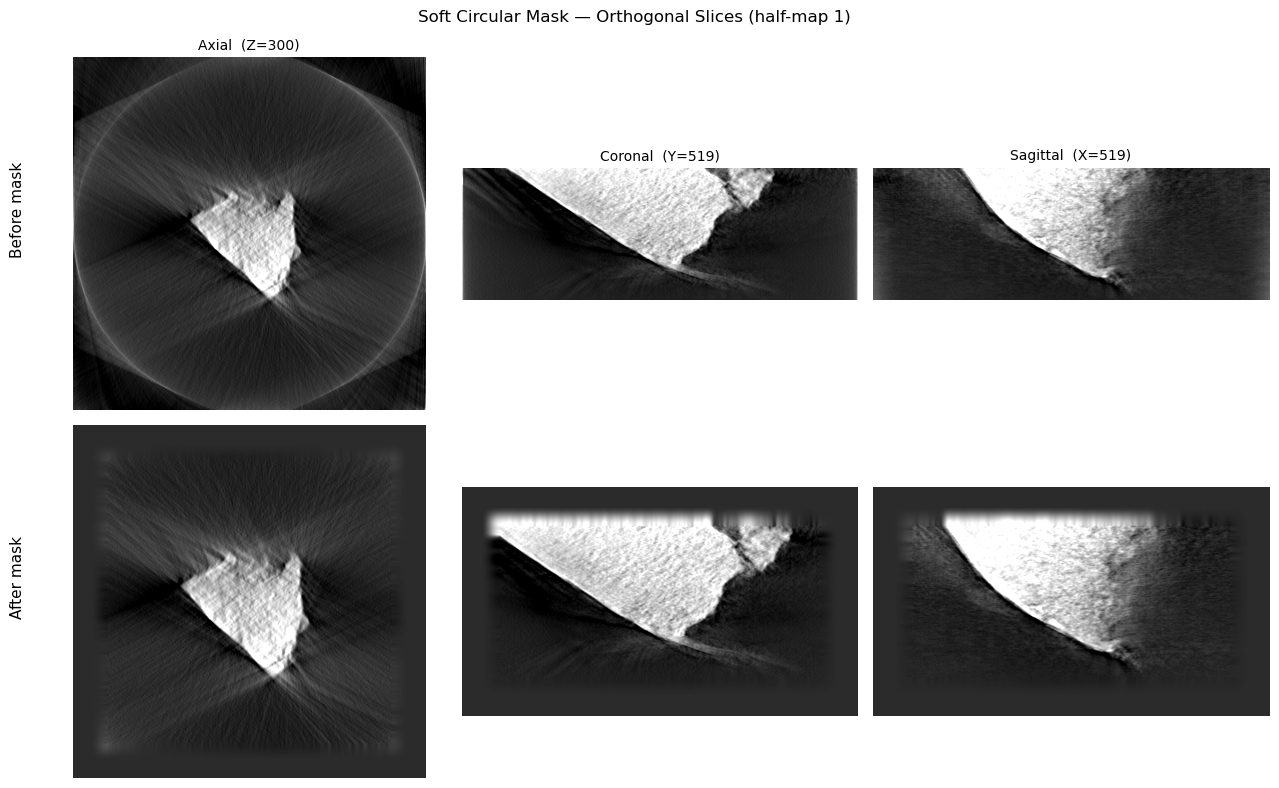

  Computing FSC …

─── Fourier Shell Correlation ────────────────────────────────
  Volume shape (half-map): (600, 1038, 1038)  |  Nyquist limit: 2.0 px
  Threshold              Freq (cyc/px)  Resolution (px)
  ─────────────────────────────────────────────────────
  half-bit                      0.2050             4.88 *
  FSC=0.5                       0.1403             7.13
  FSC=0.143                     0.2081             4.81
  3-sigma                       0.3514             2.85
  * selected threshold (half-bit)
──────────────────────────────────────────────────────────────



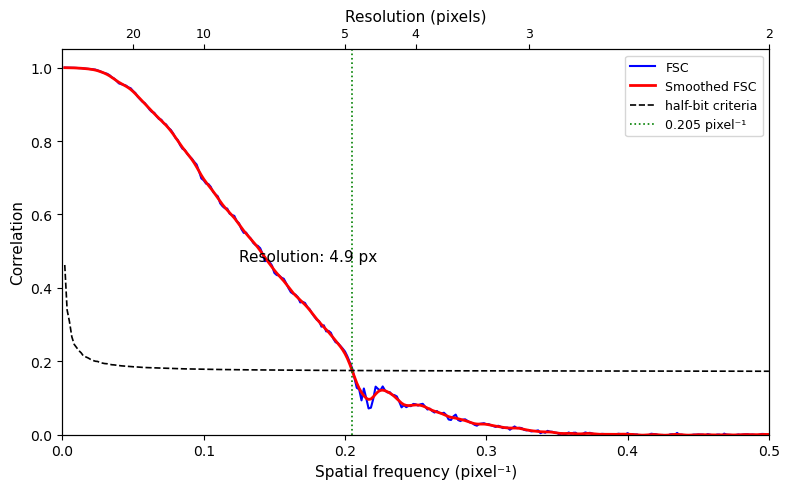

FSC computation completed in 1534.7s

FSC Resolution Thresholds
half-bit       :   4.8774 pixels
FSC=0.5        :   7.1299 pixels
FSC=0.143      :   4.8055 pixels
3-sigma        :   2.8456 pixels


In [10]:
print('\nComputing Fourier Shell Correlation (FSC)...')
t_start = time.time()
fsc_curve, fsc_resolutions, fsc_freqs = tomo.fourier_shell_correlation(
    algorithm=alg,            # SIRT_CUDA — match the full reconstruction above
    plot=True,
    smooth_sigma=2.0,         # smooth the curve so the crossing is stable against noise dips
    crop_mode = 'square',
    pad_length = pad_len,
    taper_length = pad_len//2,
    min_constraint=MinConstraint,  # match SIRT_CUDA_positivity: clip half-set recons to >= 0 each iter
)
elapsed = time.time() - t_start
print(f'FSC computation completed in {elapsed:.1f}s')

# Print resolution thresholds
print('\n' + '='*60)
print('FSC Resolution Thresholds')
print('='*60)
for threshold, resolution in fsc_resolutions.items():
    if resolution is not None:
        print(f'{threshold:15s}: {resolution:8.4f} pixels')
    else:
        print(f'{threshold:15s}: N/A (FSC never drops below threshold)')
print('='*60)


Computing Fourier Shell Correlation (FSC)...



Fourier Shell Correlation  (algorithm=SIRT_CUDA)
  Half 1 (even angles): 278 projections
  Half 2 (odd  angles): 278  projections
  Reconstructing half 1 …
  Reconstructing half 2 …
  Background-subtracted halves (median): b1=6.312e-05, b2=6.245e-05
  Pad+taper (axis 0 (top/bottom)): +100 px/face (edge-replicated), 50 px Hann taper rolling the object edge to zero → half-map shape (600, 1200, 1200)


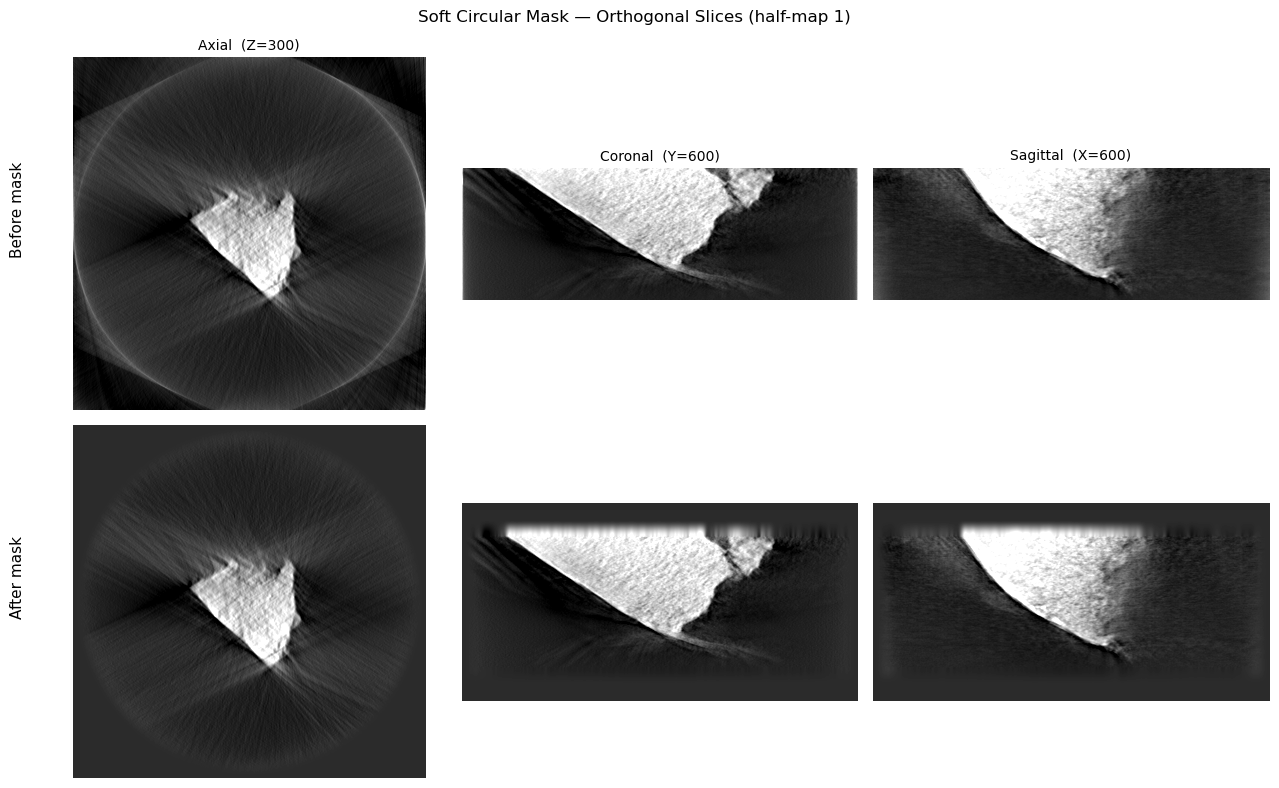

  Computing FSC …

─── Fourier Shell Correlation ────────────────────────────────
  Volume shape (half-map): (600, 1200, 1200)  |  Nyquist limit: 2.0 px
  Threshold              Freq (cyc/px)  Resolution (px)
  ─────────────────────────────────────────────────────
  half-bit                      0.2276             4.39 *
  FSC=0.5                       0.1435             6.97
  FSC=0.143                     0.2336             4.28
  3-sigma                       0.3806             2.63
  * selected threshold (half-bit)
──────────────────────────────────────────────────────────────



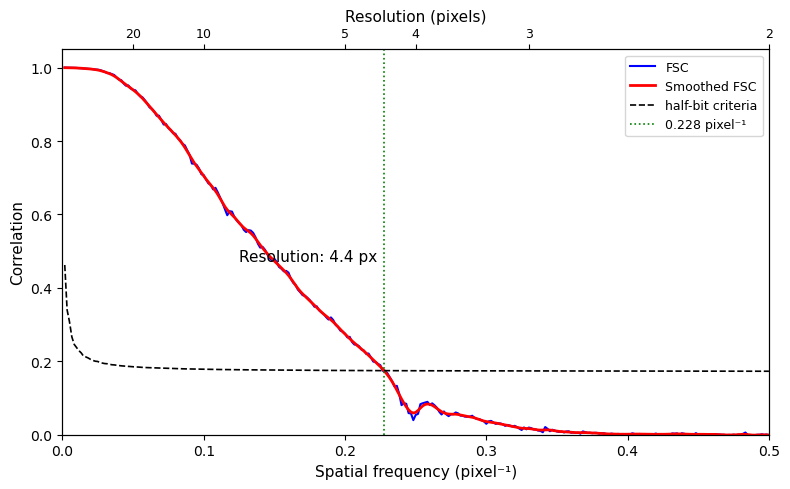

FSC computation completed in 1469.4s

FSC Resolution Thresholds
half-bit       :   4.3938 pixels
FSC=0.5        :   6.9702 pixels
FSC=0.143      :   4.2812 pixels
3-sigma        :   2.6273 pixels


In [11]:
print('\nComputing Fourier Shell Correlation (FSC)...')
t_start = time.time()
fsc_curve, fsc_resolutions, fsc_freqs = tomo.fourier_shell_correlation(
    algorithm=alg,            # SIRT_CUDA — match the full reconstruction above
    plot=True,
    smooth_sigma=2.0,         # smooth the curve so the crossing is stable against noise dips
    crop_mode = 'soft_circle',
    pad_length = pad_len,
    taper_length = pad_len//2,
    min_constraint=MinConstraint,  # match SIRT_CUDA_positivity: clip half-set recons to >= 0 each iter
)
elapsed = time.time() - t_start
print(f'FSC computation completed in {elapsed:.1f}s')

# Print resolution thresholds
print('\n' + '='*60)
print('FSC Resolution Thresholds')
print('='*60)
for threshold, resolution in fsc_resolutions.items():
    if resolution is not None:
        print(f'{threshold:15s}: {resolution:8.4f} pixels')
    else:
        print(f'{threshold:15s}: N/A (FSC never drops below threshold)')
print('='*60)

## Summary Statistics

In [12]:
print('\n' + '='*60)
print('RECONSTRUCTION SUMMARY')
print('='*60)
print(f'Algorithm:              {alg}')
print(f'Number of iterations:   {NUM_ITER}')
print(f'Extra options:          {EXTRA_OPTIONS}')
print(f'Number of projections:  {len(angles)}')
print(f'Projection angles:      [{np.degrees(angles.min()):.2f}, {np.degrees(angles.max()):.2f}] deg')
# print(f'Reconstruction shape:   {tomo.recon.shape}')
# print(f'Reconstruction range:   [{tomo.recon.min():.6f}, {tomo.recon.max():.6f}]')
# print(f'Reconstruction mean:    {tomo.recon.mean():.6f}')
# print(f'Reconstruction std:     {tomo.recon.std():.6f}')
if fsc_resolutions.get('half-bit'):
    print(f'\nFSC (half-bit):         {fsc_resolutions["half-bit"]:.4f} pixels')
if fsc_resolutions.get('FSC=0.5'):
    print(f'FSC (0.5 threshold):    {fsc_resolutions["FSC=0.5"]:.4f} pixels')
if fsc_resolutions.get('FSC=0.143'):
    print(f'FSC (0.143 threshold):  {fsc_resolutions["FSC=0.143"]:.4f} pixels')
if fsc_resolutions.get('3-sigma'):
    print(f'FSC (3-sigma):          {fsc_resolutions["3-sigma"]:.4f} pixels')
print('='*60)


RECONSTRUCTION SUMMARY
Algorithm:              SIRT_CUDA
Number of iterations:   400
Extra options:          {'MinConstraint': 0}
Number of projections:  556
Projection angles:      [-65.63, 65.17] deg

FSC (half-bit):         4.3938 pixels
FSC (0.5 threshold):    6.9702 pixels
FSC (0.143 threshold):  4.2812 pixels
FSC (3-sigma):          2.6273 pixels
